# Network Intrusion Detection — Week 2–3
## Step 1: Dataset Loading & Preprocessing (NSL-KDD)

**Project:** M.Sc. Applied Computer Science — SRH University Heidelberg  
**Author:** Atharva Gajbe

---
### What this notebook covers
1. Download NSL-KDD dataset
2. Load and inspect the data
3. Exploratory Data Analysis (EDA)
4. Clean and preprocess features
5. Save processed data for model training

## 0. Install & Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Paths
RAW_DIR  = '../data/raw/'
PROC_DIR = '../data/processed/'
FIG_DIR  = '../outputs/figures/'
os.makedirs(RAW_DIR,  exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Download NSL-KDD Dataset

NSL-KDD is hosted by the Canadian Institute for Cybersecurity.  
We download the train and test CSVs directly.

In [2]:
import urllib.request

URLS = {
    'KDDTrain+.txt': 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt',
    'KDDTest+.txt' : 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt',
}

for filename, url in URLS.items():
    dest = os.path.join(RAW_DIR, filename)
    if not os.path.exists(dest):
        print(f'Downloading {filename}...')
        urllib.request.urlretrieve(url, dest)
        print(f'  Saved to {dest}')
    else:
        print(f'{filename} already exists, skipping download.')

KDDTrain+.txt already exists, skipping download.
KDDTest+.txt already exists, skipping download.


## 2. Load the Data

In [3]:
# NSL-KDD column names (41 features + label + difficulty score)
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label', 'difficulty'
]

df_train = pd.read_csv(RAW_DIR + 'KDDTrain+.txt', names=COLUMNS)
df_test  = pd.read_csv(RAW_DIR + 'KDDTest+.txt',  names=COLUMNS)

# Drop the difficulty column (not needed for ML)
df_train.drop('difficulty', axis=1, inplace=True)
df_test.drop('difficulty',  axis=1, inplace=True)

print(f'Train shape: {df_train.shape}')
print(f'Test  shape: {df_test.shape}')
df_train.head()

Train shape: (125973, 42)
Test  shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 3. Exploratory Data Analysis (EDA)

In [4]:
print('=== Data Types ===')
print(df_train.dtypes.value_counts())
print('\n=== Missing Values ===')
print(df_train.isnull().sum().sum(), 'missing values total')
print('\n=== Duplicate Rows ===')
print(df_train.duplicated().sum(), 'duplicate rows')

=== Data Types ===
int64      23
float64    15
str         4
Name: count, dtype: int64

=== Missing Values ===
0 missing values total

=== Duplicate Rows ===
0 duplicate rows


In [5]:
# Attack label distribution
label_counts = df_train['label'].value_counts()
print('Top 15 attack labels in training set:')
print(label_counts.head(15))

Top 15 attack labels in training set:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
Name: count, dtype: int64


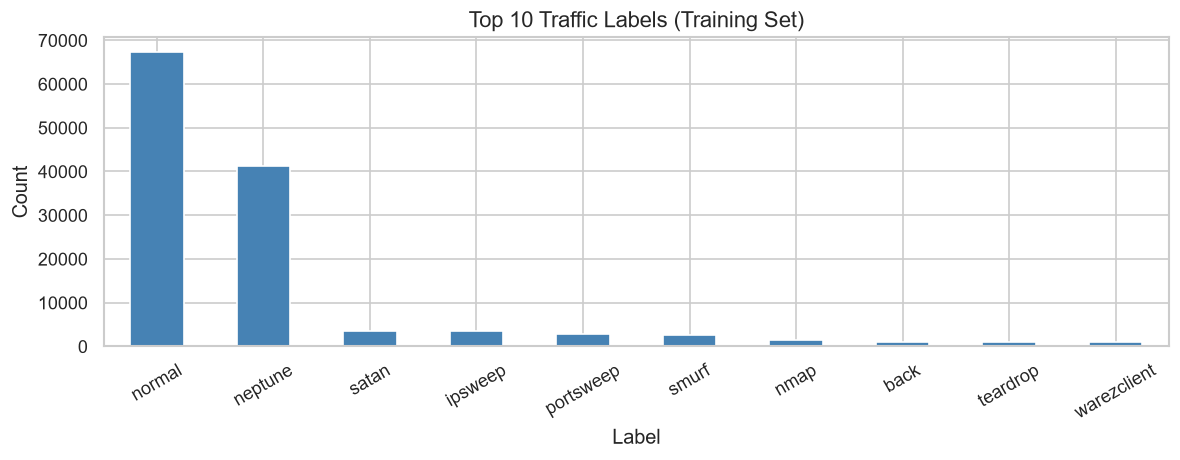

In [6]:
# Plot top 10 labels
fig, ax = plt.subplots(figsize=(10, 4))
label_counts.head(10).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 10 Traffic Labels (Training Set)', fontsize=13)
ax.set_xlabel('Label')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR + 'label_distribution.png')
plt.show()

## 4. Preprocessing

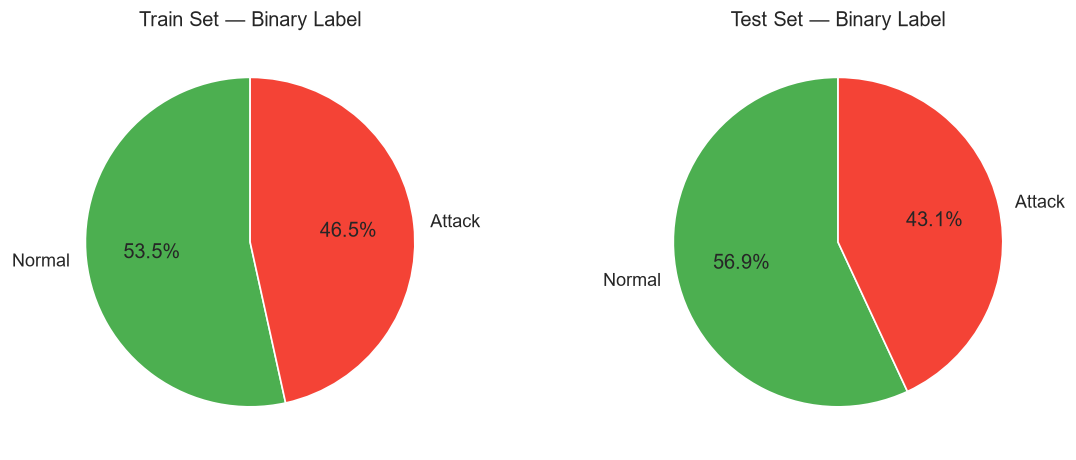

Train: {0: 67343, 1: 58630}
Test:  {1: 12833, 0: 9711}


In [7]:
# 4a. Binary label: normal=0, attack=1
df_train['binary_label'] = df_train['label'].apply(lambda x: 0 if x == 'normal' else 1)
df_test['binary_label']  = df_test['label'].apply(lambda x: 0 if x == 'normal' else 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df, title in zip(axes, [df_train, df_test], ['Train', 'Test']):
    counts = df['binary_label'].value_counts()
    ax.pie(counts, labels=['Normal', 'Attack'], autopct='%1.1f%%',
           colors=['#4CAF50', '#F44336'], startangle=90)
    ax.set_title(f'{title} Set — Binary Label')
plt.tight_layout()
plt.savefig(FIG_DIR + 'binary_class_distribution.png')
plt.show()

print('Train:', df_train['binary_label'].value_counts().to_dict())
print('Test: ', df_test['binary_label'].value_counts().to_dict())

In [8]:
# 4b. Encode categorical features
CAT_COLS = ['protocol_type', 'service', 'flag']
encoders = {}

for col in CAT_COLS:
    # Fit on combined train+test to handle all categories
    le = LabelEncoder()
    combined = pd.concat([df_train[col], df_test[col]])
    le.fit(combined)
    df_train[col] = le.transform(df_train[col])
    df_test[col]  = le.transform(df_test[col])
    encoders[col] = le
    print(f'{col}: {le.classes_.tolist()}')

protocol_type: ['icmp', 'tcp', 'udp']
service: ['IRC', 'X11', 'Z39_50', 'aol', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'harvest', 'hostnames', 'http', 'http_2784', 'http_443', 'http_8001', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'login', 'mtp', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'netstat', 'nnsp', 'nntp', 'ntp_u', 'other', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'private', 'red_i', 'remote_job', 'rje', 'shell', 'smtp', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'systat', 'telnet', 'tftp_u', 'tim_i', 'time', 'urh_i', 'urp_i', 'uucp', 'uucp_path', 'vmnet', 'whois']
flag: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']


In [9]:
# 4c. Separate features and labels
FEATURE_COLS = [c for c in df_train.columns if c not in ('label', 'binary_label')]

X_train = df_train[FEATURE_COLS].values
y_train = df_train['binary_label'].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test['binary_label'].values

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape},  y_test:  {y_test.shape}')

X_train: (125973, 41), y_train: (125973,)
X_test:  (22544, 41),  y_test:  (22544,)


In [10]:
# 4d. Normalize with MinMaxScaler (fit on train only!)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Scaling complete. Feature range after scaling:')
print(f'  Min: {X_train.min():.2f}  Max: {X_train.max():.2f}')

Scaling complete. Feature range after scaling:
  Min: 0.00  Max: 1.00


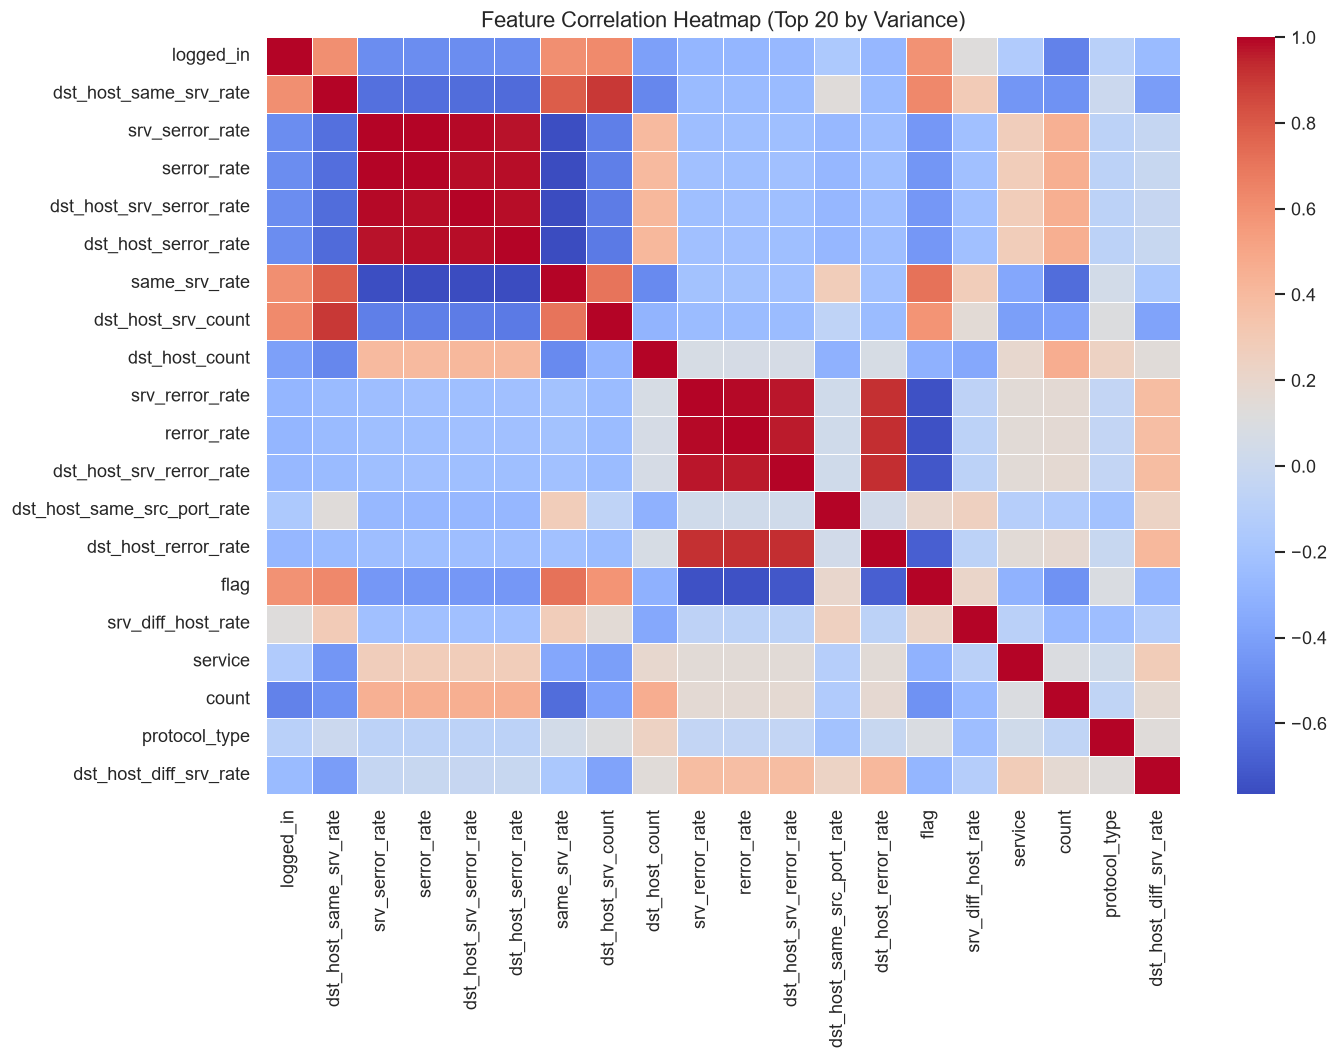

In [11]:
# 4e. Correlation heatmap (top 20 features by variance)
df_scaled = pd.DataFrame(X_train, columns=FEATURE_COLS)
top_features = df_scaled.var().nlargest(20).index

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_scaled[top_features].corr(), annot=False, cmap='coolwarm',
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap (Top 20 by Variance)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR + 'correlation_heatmap.png')
plt.show()

## 5. Save Processed Data

In [12]:
import joblib

# Save processed arrays
np.save(PROC_DIR + 'X_train.npy', X_train)
np.save(PROC_DIR + 'y_train.npy', y_train)
np.save(PROC_DIR + 'X_test.npy',  X_test)
np.save(PROC_DIR + 'y_test.npy',  y_test)

# Save scaler for use in prototype
joblib.dump(scaler, '../models/scaler.joblib')

# Save categorical encoders for use in prototype
joblib.dump(encoders, '../models/label_encoders.joblib')

# Save feature column names
pd.Series(FEATURE_COLS).to_csv(PROC_DIR + 'feature_columns.csv', index=False)

print('Saved:')
print('  data/processed/X_train.npy, y_train.npy, X_test.npy, y_test.npy')
print('  models/scaler.joblib')
print('  models/label_encoders.joblib')
print('  data/processed/feature_columns.csv')
print('\n✓ Preprocessing complete! Open 02_model_training.ipynb next.')

Saved:
  data/processed/X_train.npy, y_train.npy, X_test.npy, y_test.npy
  models/scaler.joblib
  models/label_encoders.joblib
  data/processed/feature_columns.csv

✓ Preprocessing complete! Open 02_model_training.ipynb next.
